In [2]:
import os
os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_DISABLED"] = "true"

In [3]:
# ============================================
# 👑 PPE Detection with YOLOv11 - Colab Edition
# ============================================

# STEP 1: Check GPU and Environment
!nvidia-smi
!pip install ultralytics==8.3.21 opencv-python-headless==4.10.0.84 roboflow -q

from ultralytics import YOLO
import torch

print("🔥 GPU Detected:", torch.cuda.get_device_name(0))


Tue Oct 14 08:34:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# ============================================
# STEP 2: Mount Google Drive (Optional)
# ============================================
from google.colab import drive
drive.mount('/content/drive')

# Example: store your dataset in Drive
# e.g. /content/drive/MyDrive/PPE_Dataset


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ============================================
# STEP 3: Prepare Dataset Paths
# ============================================
# Set the path where your dataset is stored
DATASET_PATH = "/content/drive/MyDrive/PPE_YOLOv11_HighAcc/data"

# Expected Structure:
# PPE_Dataset/
# ├── images/
# │   ├── train/
# │   └── val/
# ├── labels/
# │   ├── train/
# │   └── val/
# └── data.yaml

!ls {DATASET_PATH}

images	labels	ppe.yaml


In [6]:
import os
os.environ["WANDB_MODE"] = "disabled"

In [8]:
# ============================================
# STEP 4: Train the YOLOv11 Model
# ============================================
# Possible base models: yolo11n.pt (nano), yolo11s.pt (small), yolo11m.pt (medium)
# Recommended start: yolo11s.pt

from ultralytics import YOLO
import os
# 🔇 Disable wandb forever
os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_DISABLED"] = "true" # 👑 disable Weights & Biases logging

model = YOLO("yolo11s.pt")
results = model.train(
    data=f"{DATASET_PATH}/ppe.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="PPE_YOLOv11",
    device=0
)


New https://pypi.org/project/ultralytics/8.3.213 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.21 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/drive/MyDrive/PPE_YOLOv11_HighAcc/data/ppe.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=PPE_YOLOv119, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, e

100%|██████████| 5.35M/5.35M [00:00<00:00, 125MB/s]


AMP: checks passed ✅


train: Scanning /content/drive/MyDrive/PPE_YOLOv11_HighAcc/data/labels/train.cache... 1132 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1132/1132 [00:00<?, ?it/s]

train: /content/drive/MyDrive/PPE_YOLOv11_HighAcc/data/images/train/image187.jpg: 1 duplicate labels removed


...

      50/50      4.51G      1.194     0.6235      1.332         67        640: 100%|██████████| 71/71 [00:27<00:00,  2.58it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  2.62it/s]

                   all        143       1172       0.75      0.576      0.637      0.312



50 epochs completed in 0.530 hours.
Optimizer stripped from runs/detect/PPE_YOLOv119/weights/last.pt, 19.2MB
Optimizer stripped from runs/detect/PPE_YOLOv119/weights/best.pt, 19.2MB

Validating runs/detect/PPE_YOLOv119/weights/best.pt...
Ultralytics 8.3.21 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,417,057 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:04<00:00,  1.18it/s]


                   all        143       1172       0.75      0.576      0.637      0.312
                helmet        107        201       0.87      0.811      0.827      0.448
                gloves         68        136      0.823      0.751      0.808      0.399
                  vest        109        171      0.844      0.784      0.863      0.559
                 boots         64        151      0.781      0.758      0.817      0.463
               goggles         44         47      0.836      0.787      0.811      0.397
                  none         43         81      0.582      0.617      0.624      0.225
                person        139        239      0.867      0.904      0.927      0.553
             no_helmet         27         45      0.554      0.422      0.445      0.147
             no_goggle         25         41      0.631      0.195      0.281     0.0844
             no_gloves         23         56      0.461      0.304      0.313     0.0763
              no_boot

In [9]:

# ============================================
# STEP 5: Evaluate Model Performance
# ============================================
metrics = model.val()
print(metrics)


Ultralytics 8.3.21 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,417,057 parameters, 0 gradients, 21.3 GFLOPs


val: Scanning /content/drive/MyDrive/PPE_YOLOv11_HighAcc/data/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100%|██████████| 143/143 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:05<00:00,  1.51it/s]


                   all        143       1172      0.739      0.591      0.639      0.315
                helmet        107        201      0.867      0.816      0.824      0.449
                gloves         68        136      0.833      0.772      0.815        0.4
                  vest        109        171      0.842      0.795       0.86      0.558
                 boots         64        151      0.777      0.762      0.818      0.463
               goggles         44         47      0.831      0.787      0.811      0.398
                  none         43         81      0.597      0.623      0.632       0.24
                person        139        239      0.863      0.904      0.927      0.554
             no_helmet         27         45      0.504      0.467      0.461      0.156
             no_goggle         25         41      0.508       0.22      0.288     0.0857
             no_gloves         23         56      0.509      0.352        0.3     0.0734
              no_boot

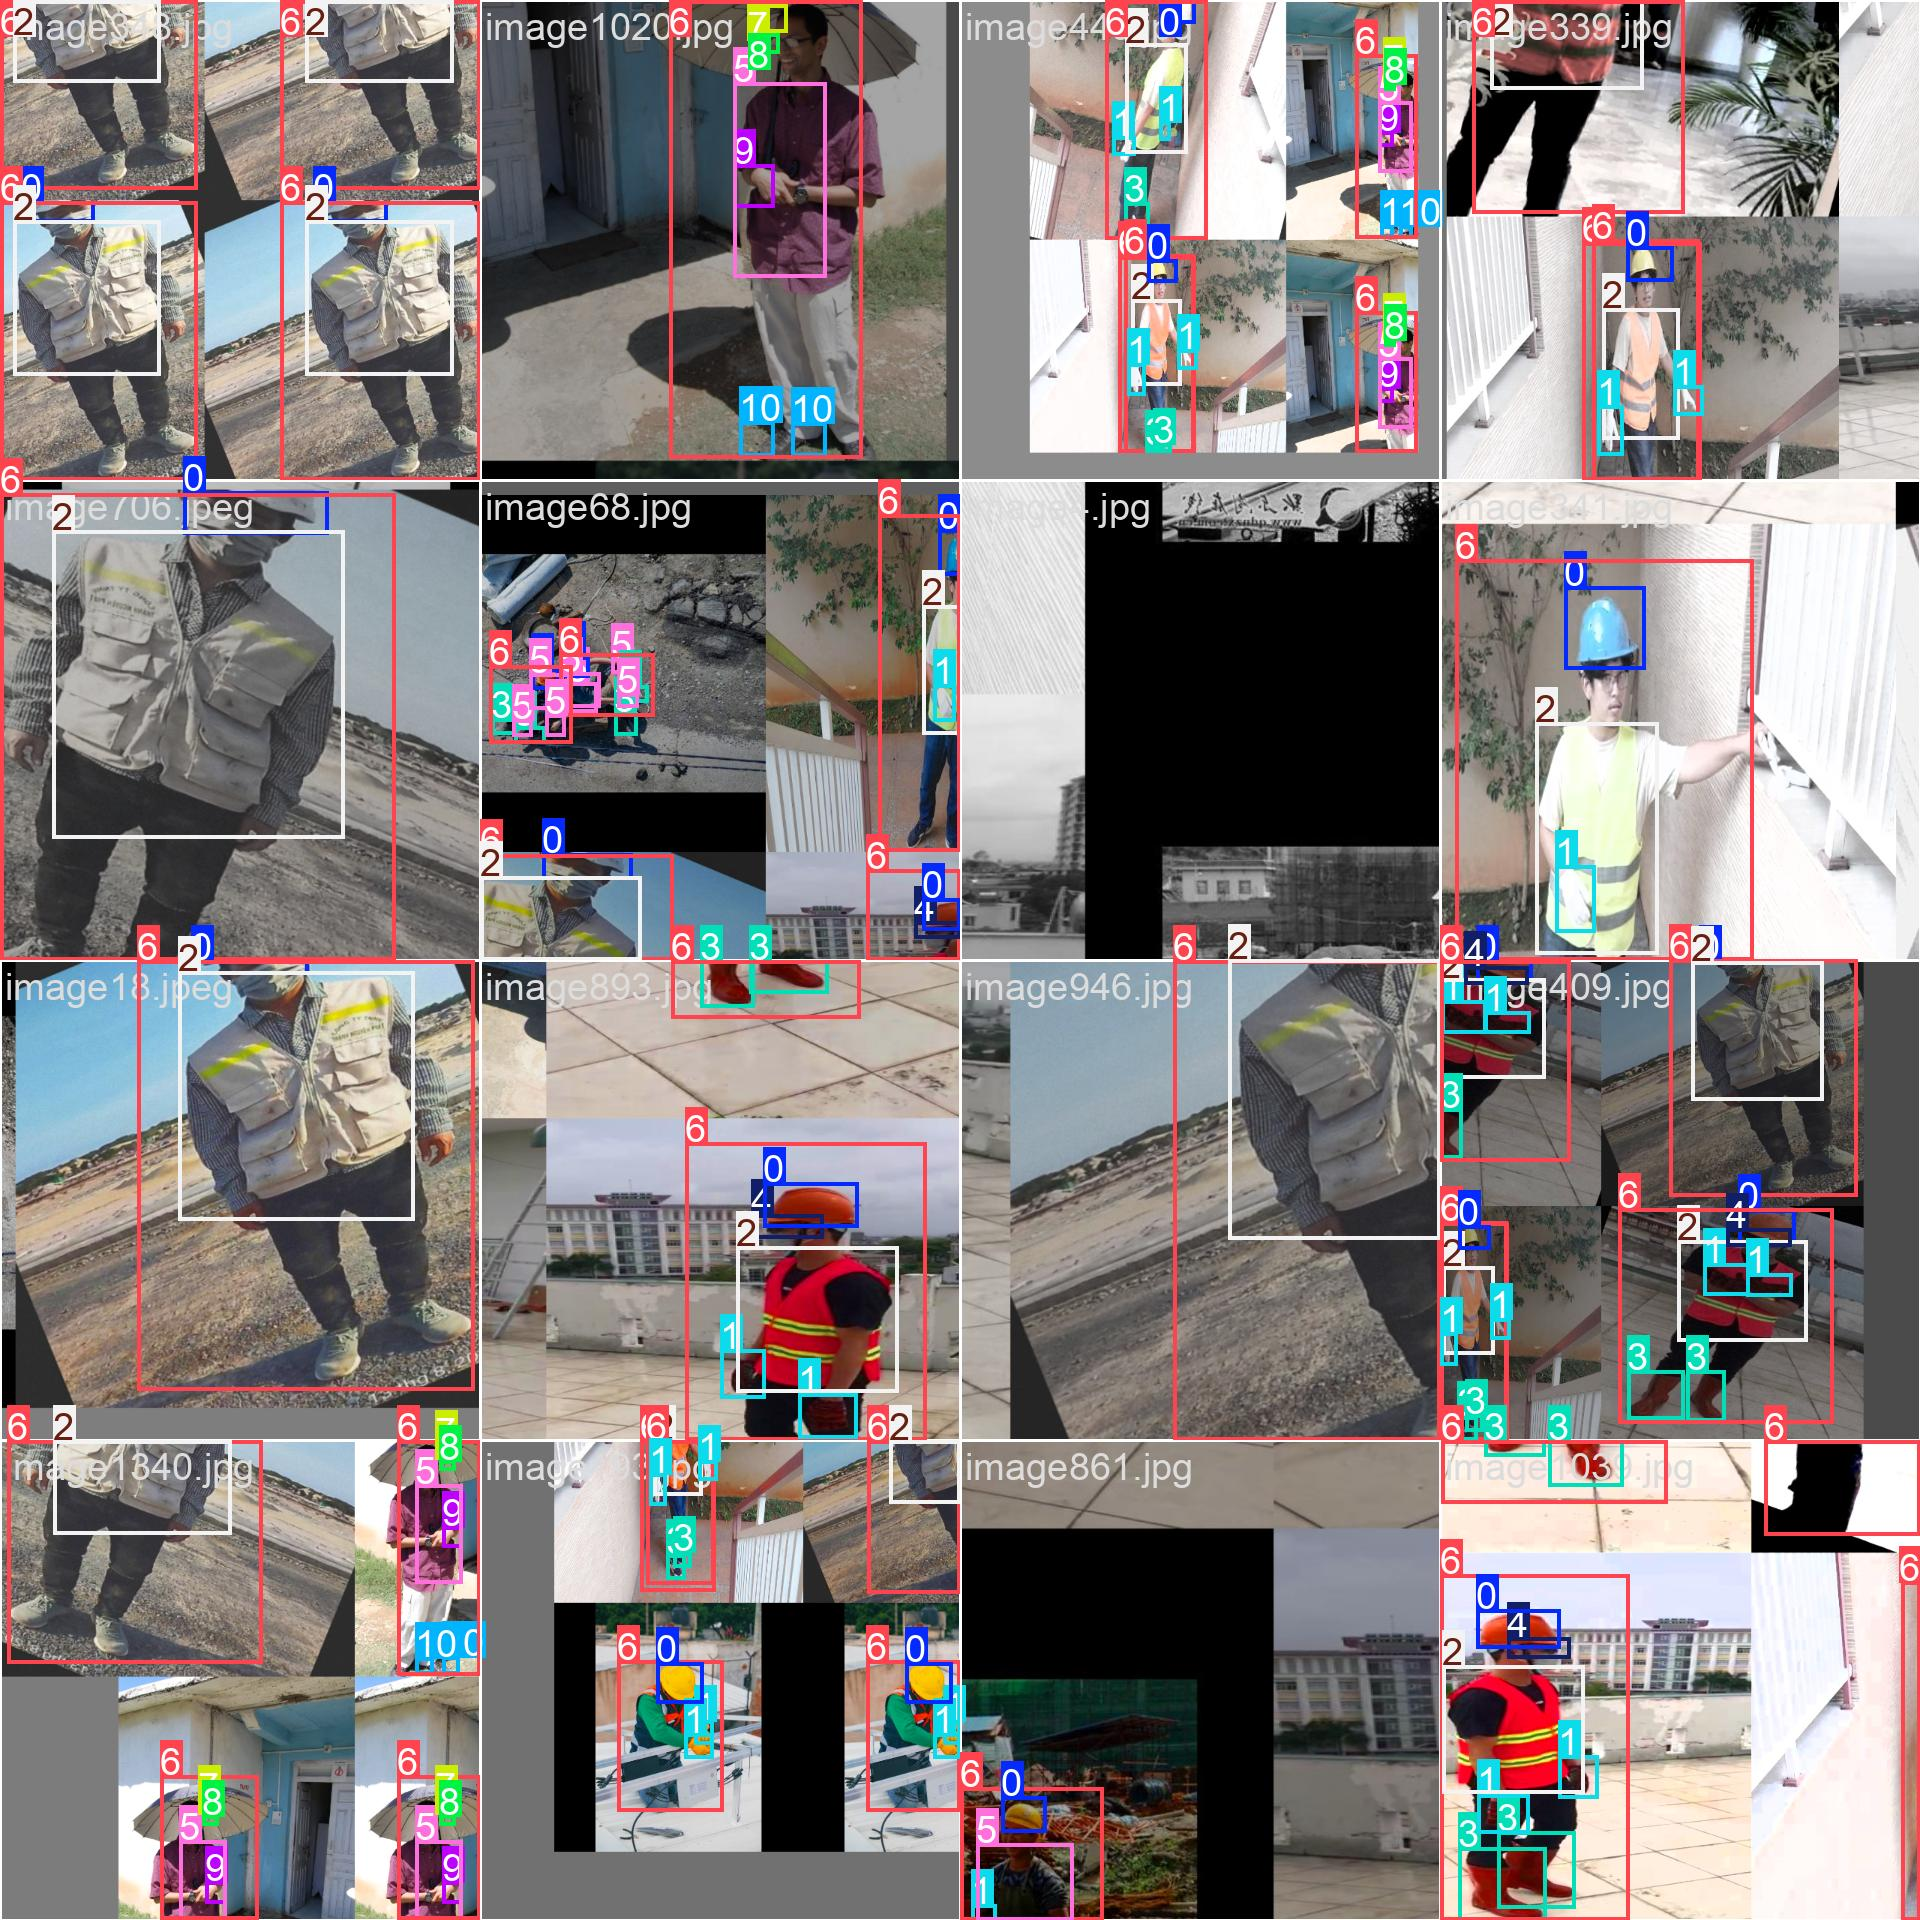

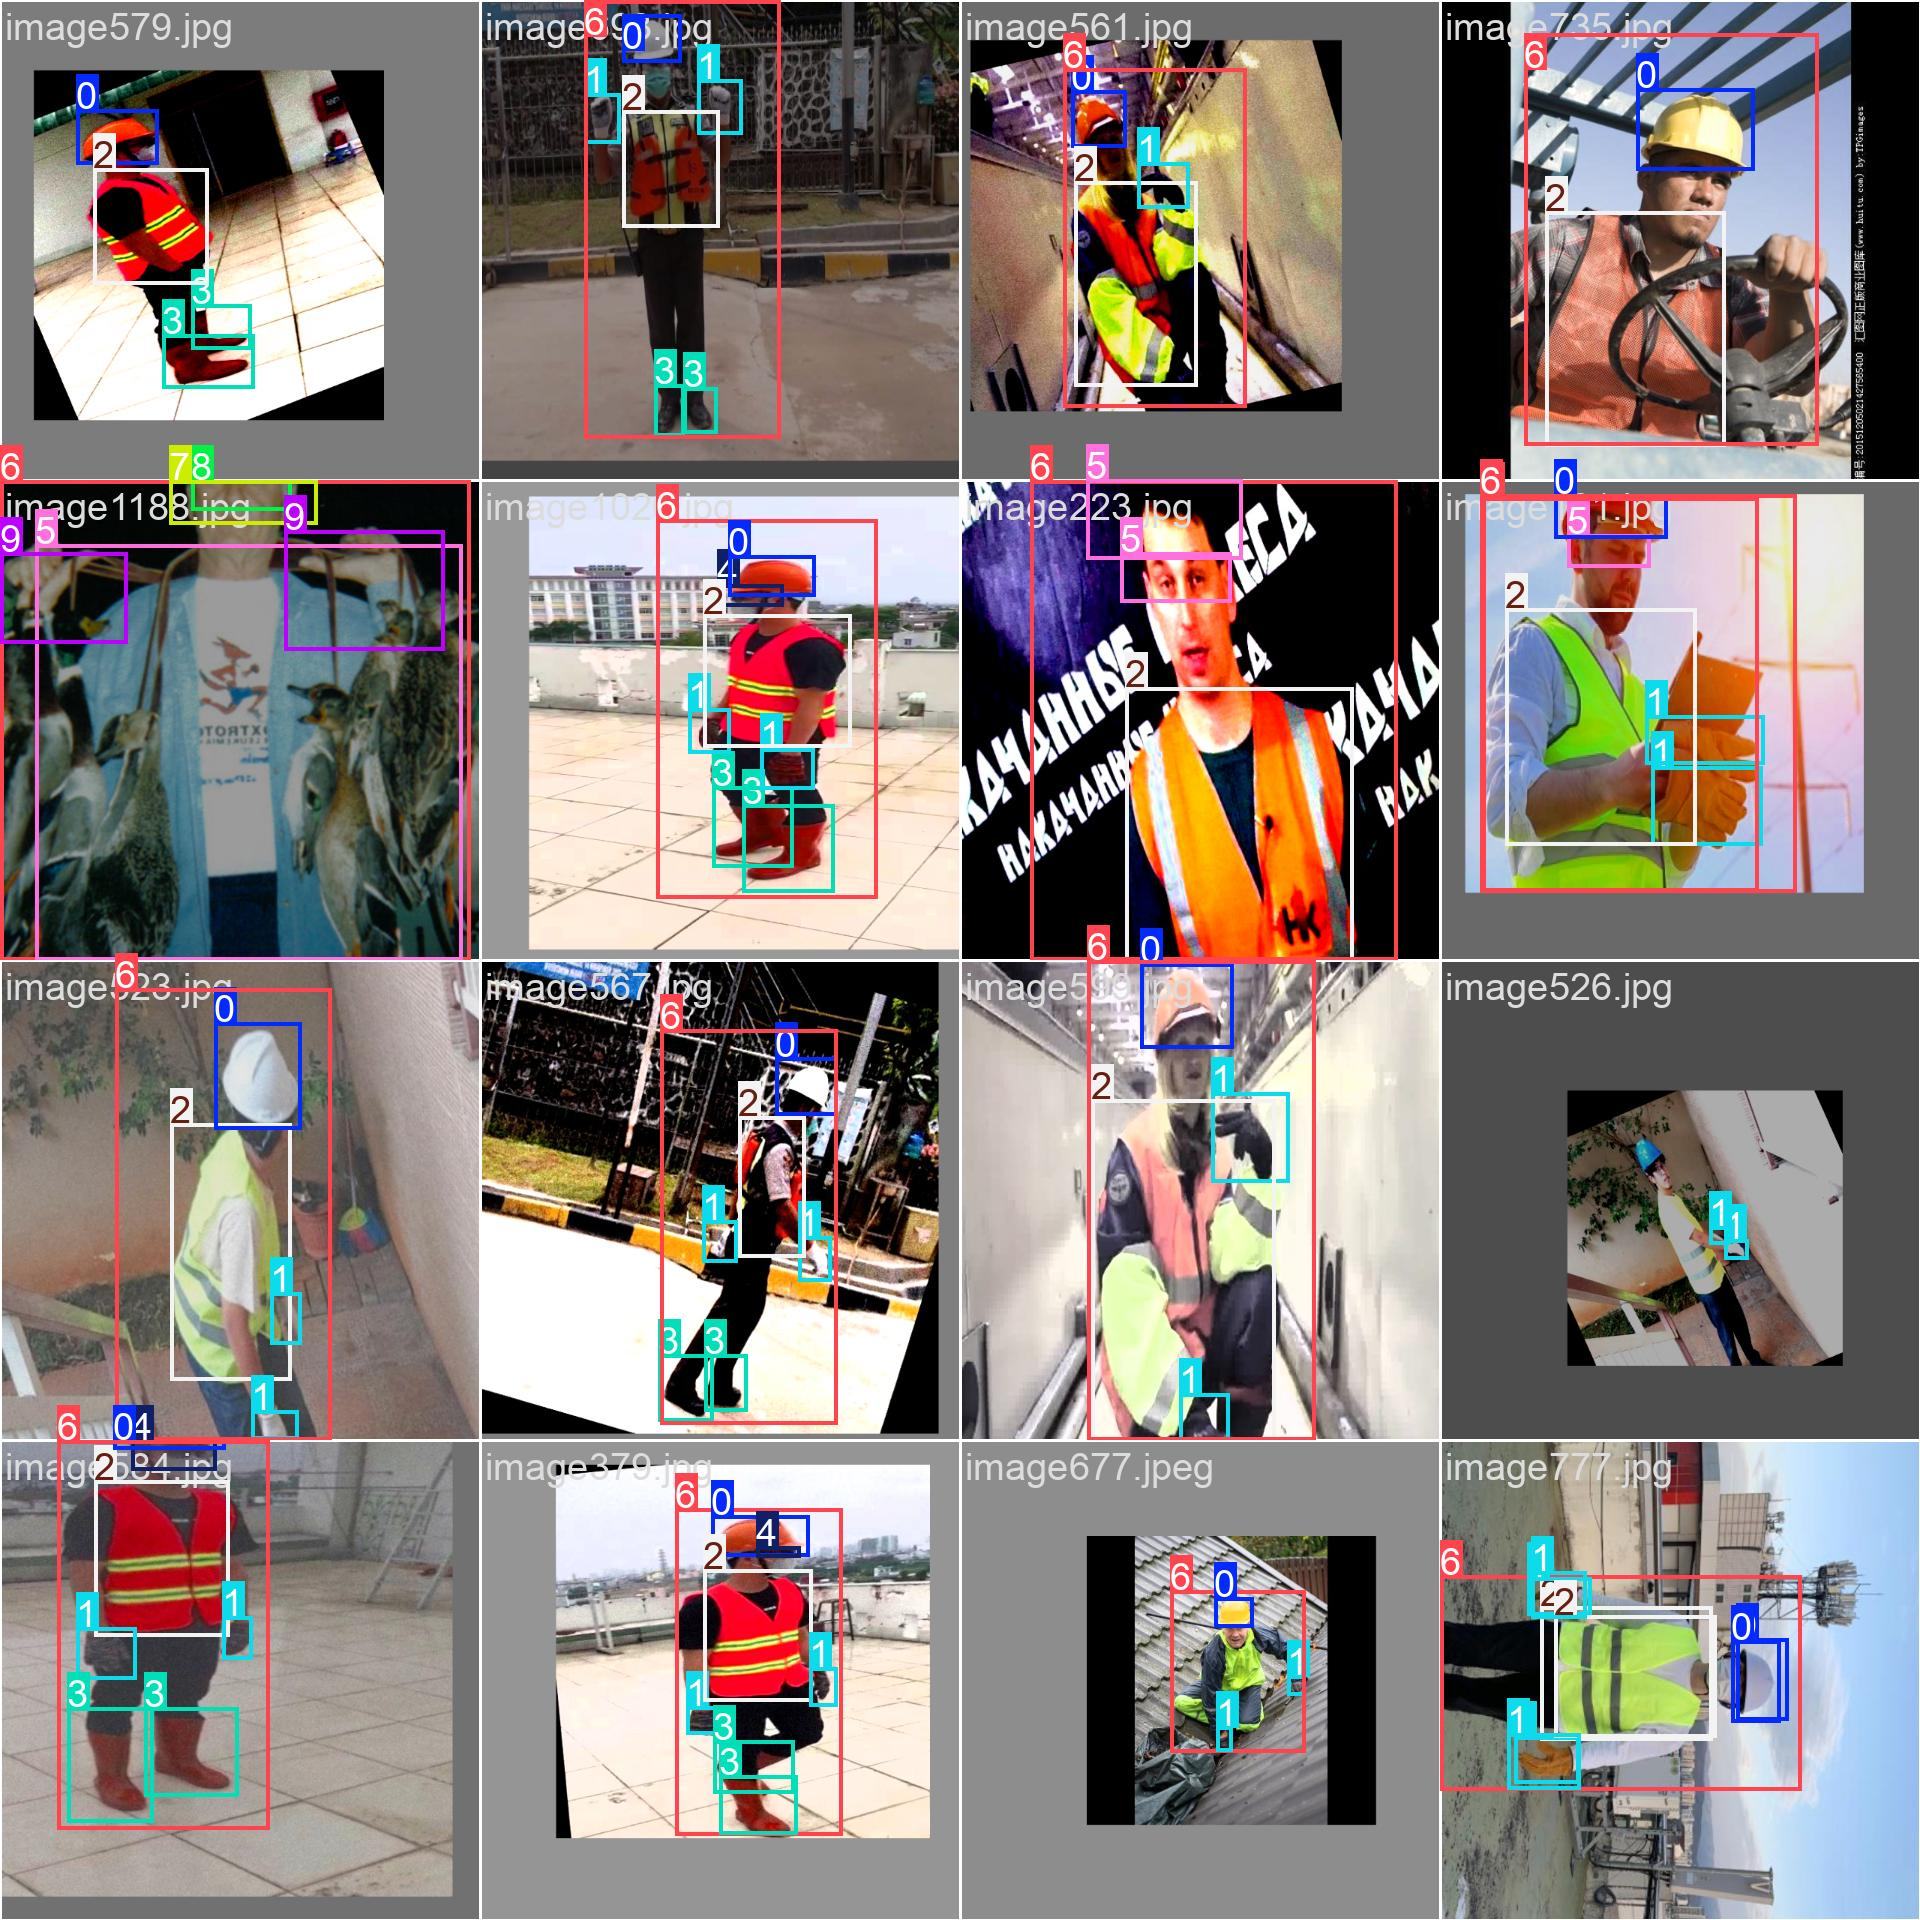

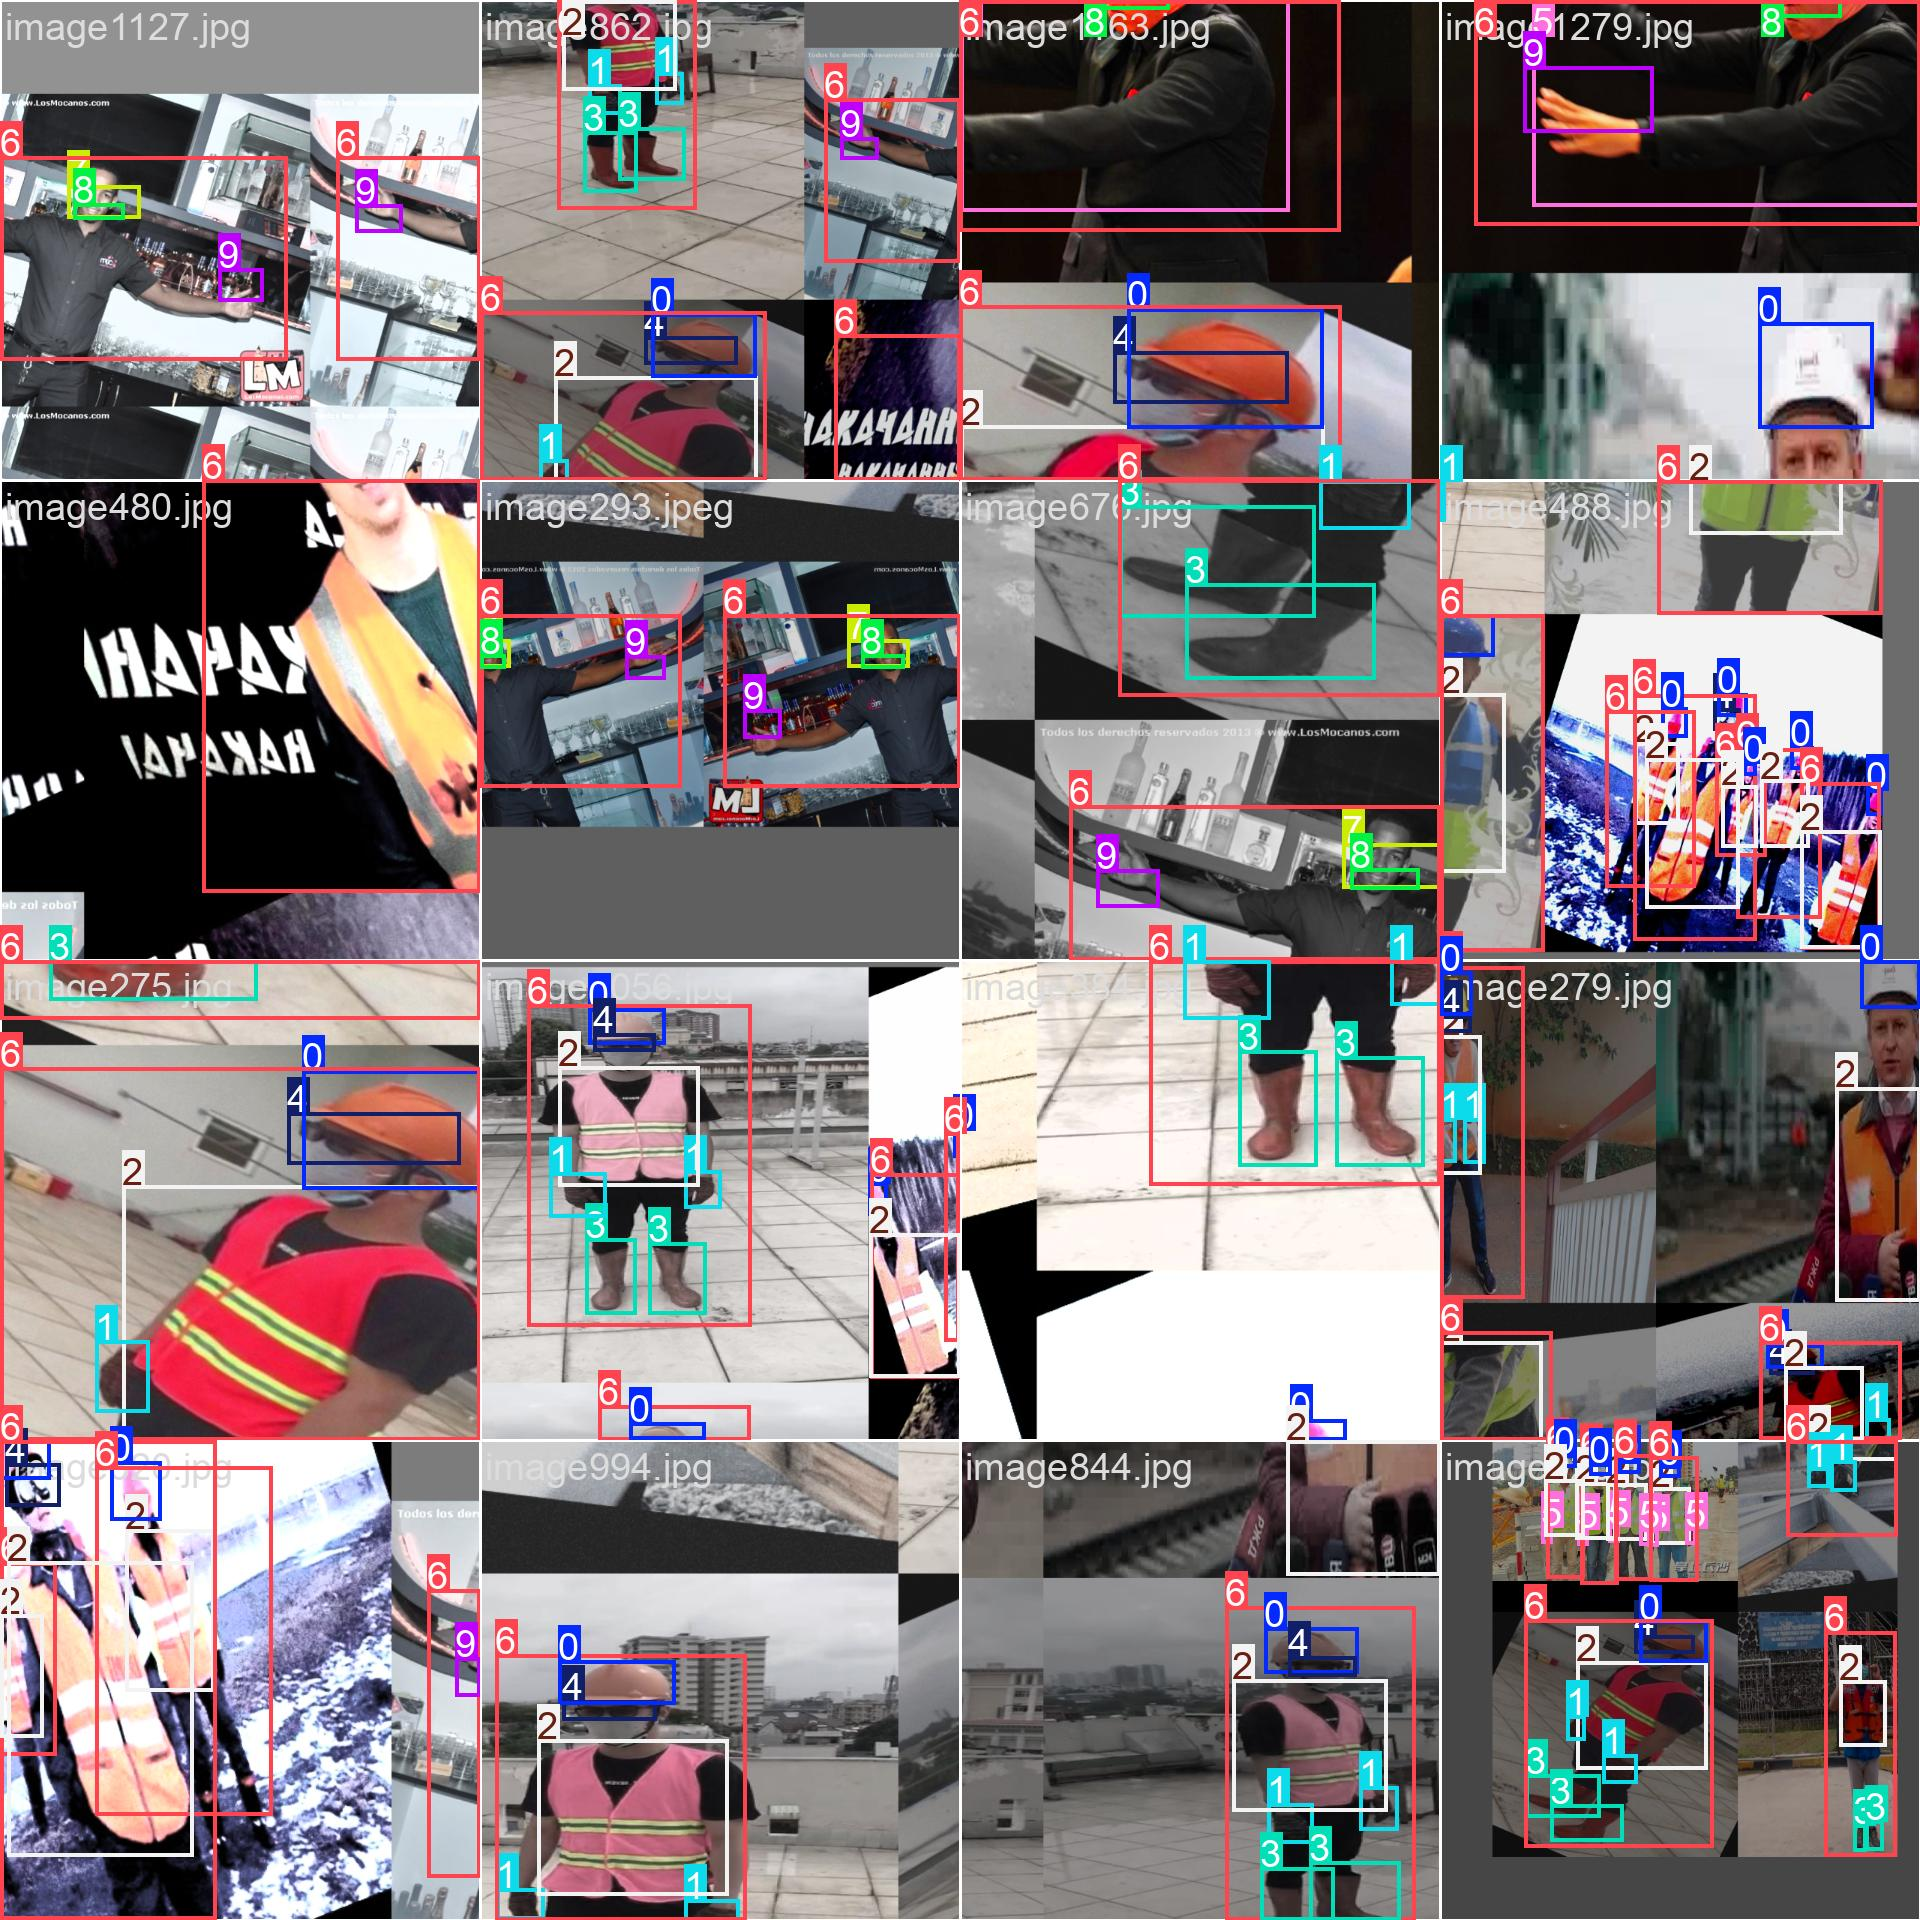

In [10]:
# ============================================
# STEP 6: Visualize Results
# ============================================
from IPython.display import Image, display
import glob

result_images = glob.glob("runs/detect/PPE_YOLOv11*/train*.jpg")
for img_path in result_images[:3]:
    display(Image(filename=img_path))


In [ ]:
# ============================================
# STEP 7: Run Inference on Test Image/Video
# ============================================
TEST_IMAGE = f"{DATASET_PATH}/images/val/sample.jpg"  # change path
model.predict(source=TEST_IMAGE, conf=0.25, save=True)


In [13]:
# ============================================
# STEP 8: Export Trained Model
# ============================================
!mkdir -p /content/drive/MyDrive/PPE_Models
!cp /content/runs/detect/PPE_YOLOv119/weights/best.pt /content/drive/MyDrive/PPE_Models/best.pt

print("✅ Model saved at: /content/drive/MyDrive/PPE_Models/best.pt")

✅ Model saved at: /content/drive/MyDrive/PPE_Models/best.pt
